<a href="https://colab.research.google.com/github/yelenana/machine_learning/blob/main/Rybchynska_Olena_%22Mid_term_Project_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

# 1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку y.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls drive/MyDrive/ML/mid_term/

Mounted at /content/drive
bank-additional-full.csv  script


In [2]:
import pandas as pd
df=pd.read_csv('drive/MyDrive/ML/mid_term/bank-additional-full.csv', sep=';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Опис датасету

Датасет Bank Marketing містить інформацію про маркетингові дзвінки банку клієнтам з метою продажу строкового депозиту.

Цільова змінна:
- y:
    - yes — клієнт погодився на депозит
    - no — клієнт відмовився

Датасет містить:
- числові ознаки
- категоріальні ознаки
- економічні показники
- інформацію про попередні контакти з клієнтами

# Перевірка структури даних

In [3]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.shape

(41188, 21)

- маємо 41188 рядків та 21 колонку

# Статистичний звіт для числових змінних

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Набір даних містить 41188 значень, частина ознак числові, а частина - категоріальні. Цільова змінна також категоріальна і має бути перекодована у числову

# Аналіз числових змінних

In [6]:
number_df = df.select_dtypes(include="number")

In [7]:
number_df.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [8]:
# Перевірка кількості числових змінних
len(number_df.columns)

10

# Аналіз категоріальних змінних

In [9]:
df.select_dtypes(include = "object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [10]:
# Перевірка кількості категоріальних змінних
len(df.select_dtypes(include = "object").columns)

11

# Робота з пропущеними значеннями

Набір даних не містить пропусків, як такових. Але помітила також значення "unknown" у стовпчиках "education",	"default", дивлюся скільки таких значень взагалі у таблиці

In [11]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [12]:
unknown_count = (df == "unknown").sum()
unknown_percentage = round((unknown_count / df.shape[0]) * 100, 2)
unknown_df = pd.DataFrame({
    'column_name': df.columns,
    'unknown_count': unknown_count,
    'unknown_percentage': unknown_percentage
})
unknown_df = unknown_df[unknown_df['unknown_count'] > 0]
unknown_df.sort_values(by='unknown_percentage', ascending=False)

,column_name,unknown_count,unknown_percentage
default,default,8597,20.87
education,education,1731,4.20
housing,housing,990,2.40
loan,loan,990,2.40
job,job,330,0.80
marital,marital,80,0.19


Найбільше значення "unknown" зустрічається для змінної default - 21% (8597/41188=~0,21), а для стовпчика education таких значень приблизно 4,2%. Тобто нема таких стовпчиків, де б значення "unknown" переважало 40%, отже видаляти за чим принципом стовпці нема потреби

Ознака `duration` показує тривалість дзвінка. Вона може мати сильний зв’язок із цільовою змінною, але її значення стає відомим лише після завершення дзвінка. Тому використання цієї ознаки створює витік даних (data leakage), і її потрібно виключити з моделі.

In [13]:
df_model = df.drop("duration", axis=1)
df_model

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


перед наступною обробкою даних варто перетворити "unknown" на NaN, адже зараз це виглядає як звичайна категорія, але по суті це відсутня інформація

In [14]:
import numpy as np

In [15]:
df_model = df_model.replace('unknown', np.nan)

In [16]:
df_model.isnull().sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


Пройдемось окремо по кожному стовпцику

**Ознака 'default':**

In [17]:
df_model['default'].value_counts(dropna=False)

,count
default,
no,32588
NaN,8597
yes,3


Заповнення NaN  модою є поганою ідеєю для "default" адже це буде грубим викривленням даних і 8597 значень станіть "no", тобто для цього стовпчика краще окремо залишити категорію "unknown"

In [18]:
df_model['default'] = df_model['default'].fillna('unknown')

**Ознака  "education" :**

In [19]:
df_model['education'].value_counts(dropna=False)

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
NaN,1731
illiterate,18


Для "education" пропусків приблизно 4%, тому заповнення пропусків модою - буде нормальним рішенням

In [20]:
df_model['education'] = df_model['education'].fillna(
    df_model['education'].mode()[0]
)

**Ознака "housing":**

In [21]:
df_model['housing'].value_counts(dropna=False)

,count
housing,
yes,21576
no,18622
NaN,990


тут пропусків мало (~2.4%), так що можна заповнити модою

In [22]:
df_model['housing'] = df_model['housing'].fillna( df_model['housing'].mode()[0] )

**Ознака "loan":** - аналогічно до попередньої, тож і рішення про заміну модою пропусків - аналогічне

In [23]:
df_model['loan'].value_counts(dropna=False)

,count
loan,
no,33950
yes,6248
NaN,990


In [24]:
df_model['loan'] = df_model['loan'].fillna(
    df_model['loan'].mode()[0]
)

**І останні 2 стовпчики:** job та marital

In [25]:
df_model['job'] = df_model['job'].fillna(
    df_model['job'].mode()[0]
)

df_model['marital'] = df_model['marital'].fillna(
    df_model['marital'].mode()[0]
)

Перевіряю, що тепер NaN значення відсутні

In [26]:
df_model.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


# Перевірка дисбалансу для цільового стовпця

Також варто перевірити збалансованість класів цільової змінної:

In [27]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


Отже є явний перекіс значень цільової змінної у сторону непідписання клієнтом строкового депозиту

# Аналіз числових змінних

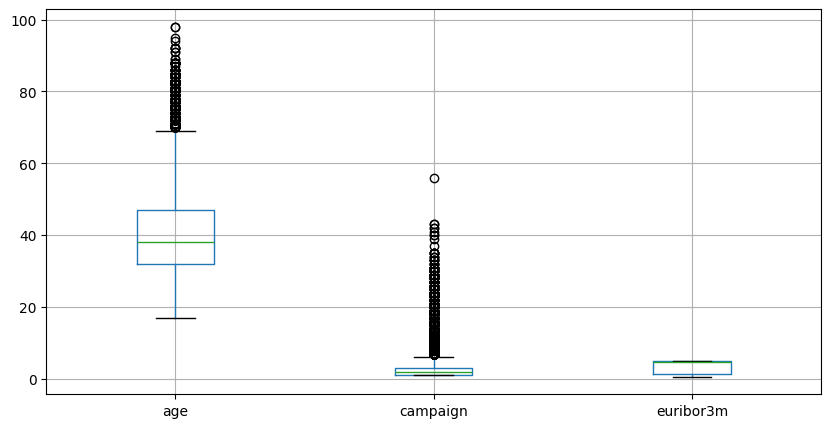

In [28]:
import matplotlib.pyplot as plt
df_model[['age','campaign','euribor3m']].boxplot(figsize=(10,5))
plt.show()

З графіку видно що:

- Ознака age має відносно нормальний розподіл із наявністю викидів (старші клієнти).
- Ознака campaign є сильно асиметричною: більшість клієнтів контактували 1–3 рази, проте є окремі значення з великою кількістю контактів.
- Ознака euribor3m має більш компактний розподіл без значних викидів.

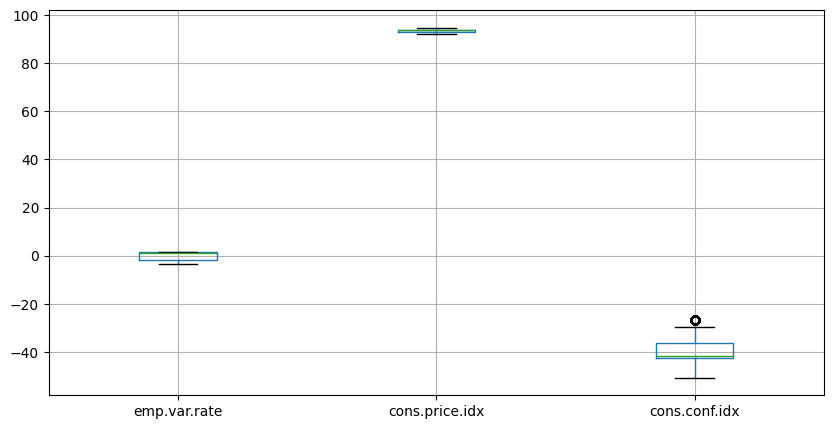

In [29]:
df_model[['emp.var.rate','cons.price.idx','cons.conf.idx']].boxplot(figsize=(10,5))
plt.show()

Економічні показники (emp.var.rate ( темп зміни зайнятості), cons.price.id ( індекс споживчих цін), cons.conf.idx( індекс довіри споживачів) мають відносно стабільні розподіли без значних викидів.

Ознака cons.price.idx має дуже вузький діапазон значень, що свідчить про низьку варіативність.


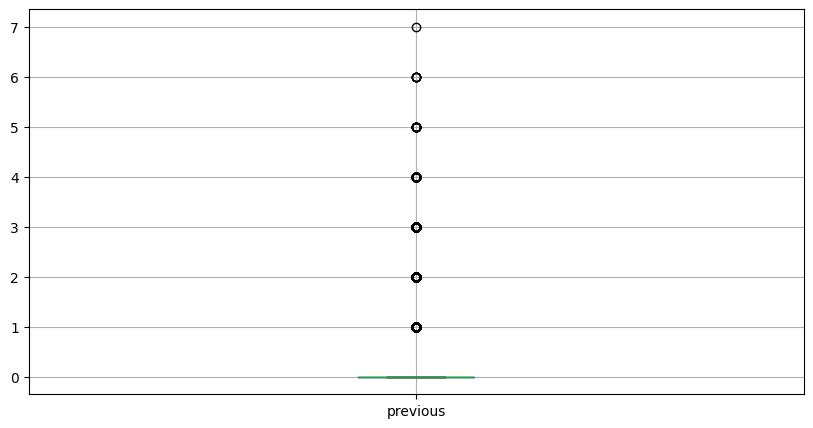

In [30]:
df_model[['previous']].boxplot(figsize=(10,5))
plt.show()

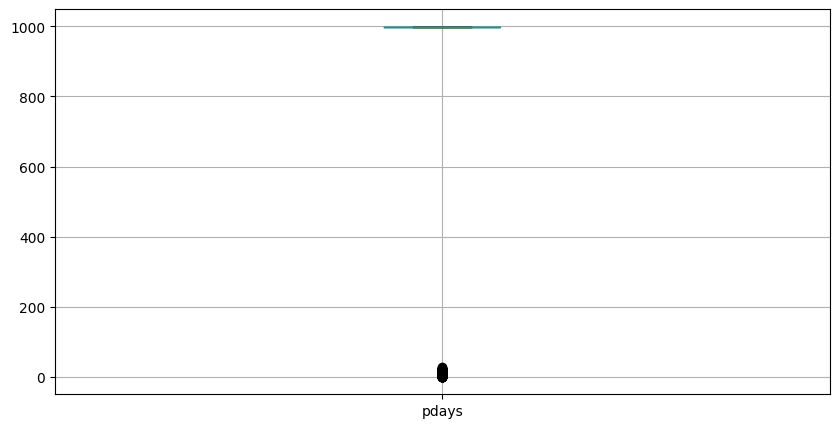

In [31]:
df_model[['pdays']].boxplot(figsize=(10,5))
plt.show()

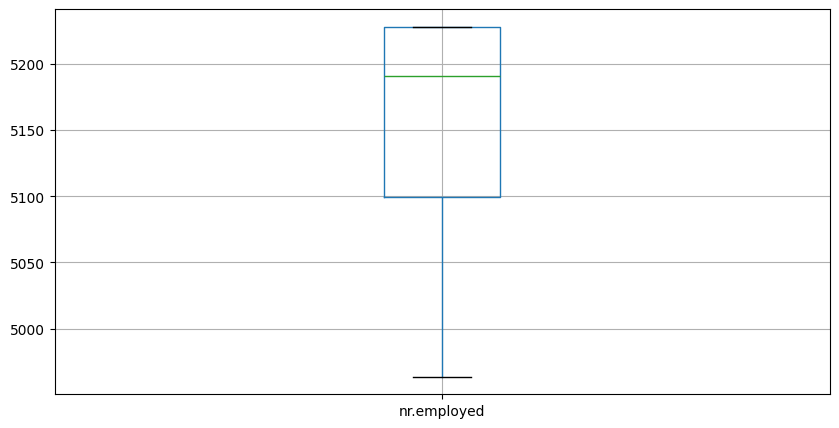

In [32]:
df_model[['nr.employed']].boxplot(figsize=(10,5))
plt.show()

Висновок:

Ознака previous показує, що більшість клієнтів не мали попередніх контактів, оскільки значення переважно дорівнюють нулю.

Ознака pdays має специфічну структуру: значення 999 означає відсутність попереднього контакту, тому ця ознака фактично поєднує дві групи клієнтів.

Ознака nr.employed має стабільний розподіл без значних викидів.

Крім того, час аналізу числових змінних було виявлено наявність викидів у деяких ознаках, зокрема `age`, `campaign` та `previous`.

Оскільки моделі дерева рішень та бустинг є достатньо стійкими до викидів, а видалення таких значень могло б призвести до втрати важливої інформації, було прийнято рішення не видаляти outliers з датасету.

**Аналіз кореляцій між числовими даними:**

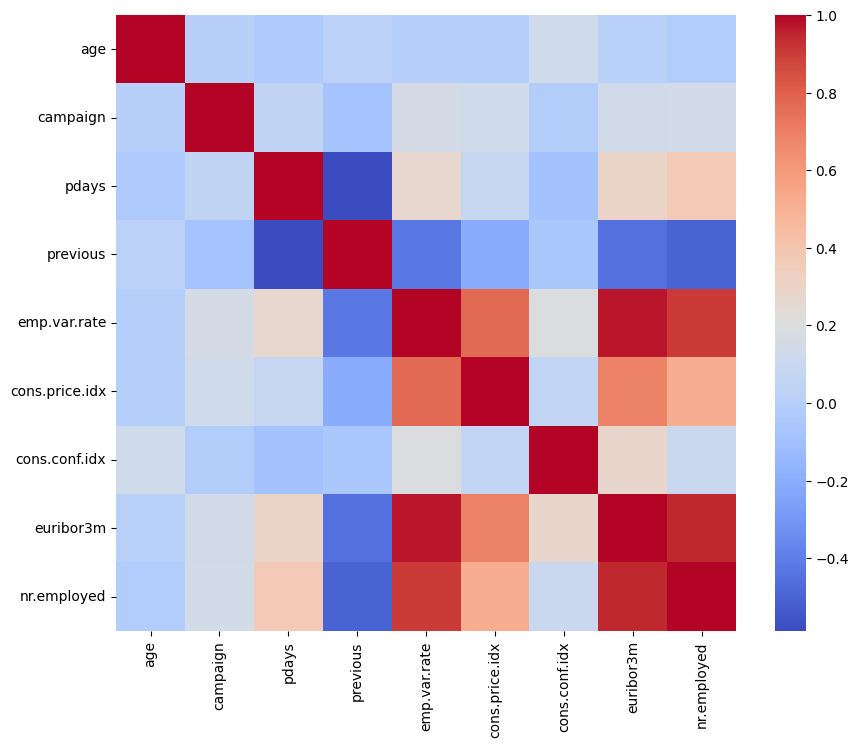

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(numeric_only=True), cmap='coolwarm')
plt.show()

Спостереження:
Кореляційна матриця показує наявність сильної позитивної кореляції між економічними показниками (`emp.var.rate`, `euribor3m`, `nr.employed`), що може свідчити про мультиколінеарність.

Також спостерігається негативна кореляція між ознаками `previous` та `pdays`, що є логічним з огляду на їх зміст(якщо були попередні контакти (previous),
то pdays менше).

# 2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

Отже за результатами виконання 1-го пункту я бачу, що у даних є:

- числові ознаки

- категоріальні

- нелінійні залежності

- дисбаланс класів

Отже, для задачі бінарної класифікації було обрано кілька моделей машинного навчання, які працюють за різними принципами.

Logistic Regression використовується як базова модель для задач класифікації. Вона проста, інтерпретована та дозволяє отримати базове розуміння якості моделі.

kNN був обраний для перевірки підходу, в якому прогноз залежить від схожості клієнтів між собою.

Decision Tree дозволяє знаходити нелінійні залежності між ознаками та цільовою змінною, а також дає можливість краще зрозуміти логіку прийняття рішень моделлю.

Boosting-модель використовується для покращення якості прогнозування за рахунок комбінування кількох моделей.

Обгрунтуванння метрики: оскільки датасет є незбалансованим (більшість клієнтів належать до класу "no"), метрика Accuracy не є достатньо показовою.

Основною метрикою оцінки якості моделей було обрано ROC-AUC, оскільки вона добре підходить для задач з незбалансованими класами та дозволяє оцінити здатність моделі розділяти класи.



# 3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати

  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

In [34]:
import os

path = '/content/drive/MyDrive/ML/mid_term/script'

print(os.path.exists(path))
print(os.listdir(path))

True
['process_script.py', '__pycache__']


In [35]:
import sys
sys.path.insert(0, path)
from process_script import preprocess_data

На етапі preprocessing дані розділяються на тренувальну та валідаційну вибірки, числові ознаки масштабуються за допомогою MinMaxScaler, а категоріальні ознаки кодуються за допомогою OneHotEncoder.

In [36]:
data = preprocess_data(df_model)
data

{'X_train':             age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 25611  0.395062  0.054545    1.0  0.000000      0.687500        0.389322   
 26010  0.246914  0.018182    1.0  0.142857      0.687500        0.389322   
 40194  0.753086  0.000000    1.0  0.000000      0.354167        0.784879   
 297    0.234568  0.018182    1.0  0.000000      0.937500        0.698753   
 36344  0.518519  0.018182    1.0  0.000000      0.104167        0.296960   
 ...         ...       ...    ...       ...           ...             ...   
 40205  0.135802  0.000000    1.0  0.000000      0.354167        0.784879   
 27316  0.432099  0.000000    1.0  0.142857      0.687500        0.389322   
 14392  0.456790  0.054545    1.0  0.000000      1.000000        0.669135   
 7494   0.148148  0.000000    1.0  0.000000      0.937500        0.698753   
 10747  0.222222  0.036364    1.0  0.000000      1.000000        0.882307   
 
        cons.conf.idx  euribor3m  nr.employed  job_admin.  ... 

# 4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково

In [37]:
X_train = data['X_train']
X_val = data['X_val']

train_targets = data['train_targets'].map({'no': 0, 'yes': 1})
val_targets = data['val_targets'].map({'no': 0, 'yes': 1})

**Logistic Regression**

In [38]:
X_train

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
25611,0.395062,0.054545,1.0,0.000000,0.687500,0.389322,0.368201,0.790297,0.877883,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
26010,0.246914,0.018182,1.0,0.142857,0.687500,0.389322,0.368201,0.790297,0.877883,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
40194,0.753086,0.000000,1.0,0.000000,0.354167,0.784879,0.439331,0.053503,0.105860,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
297,0.234568,0.018182,1.0,0.000000,0.937500,0.698753,0.602510,0.957379,0.859735,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
36344,0.518519,0.018182,1.0,0.000000,0.104167,0.296960,0.418410,0.142371,0.425709,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,0.135802,0.000000,1.0,0.000000,0.354167,0.784879,0.439331,0.054863,0.105860,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27316,0.432099,0.000000,1.0,0.142857,0.687500,0.389322,0.368201,0.767853,0.877883,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14392,0.456790,0.054545,1.0,0.000000,1.000000,0.669135,0.338912,0.981183,1.000000,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7494,0.148148,0.000000,1.0,0.000000,0.937500,0.698753,0.602510,0.958966,0.859735,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Перевіримо пропорції класів у train і validation наборі

In [39]:
print(train_targets.value_counts(normalize=True))
print(val_targets.value_counts(normalize=True))

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


Отже, пропорції класів майже ідентичні

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model=LogisticRegression(solver='liblinear')

In [42]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [43]:
model.coef_.round(2)

array([[-0.  , -1.95, -1.12, -0.43, -4.28,  3.05,  0.52,  0.69, -0.17,
        -0.01, -0.14, -0.05, -0.07, -0.03,  0.31, -0.05, -0.15,  0.15,
        -0.01, -0.03, -0.09, -0.02,  0.04, -0.13,  0.02, -0.18, -0.11,
         0.46, -0.12, -0.03,  0.14, -0.1 , -0.11, -0.01, -0.06, -0.04,
        -0.03,  0.27, -0.34, -0.06,  0.17,  0.3 ,  0.05, -0.35,  1.13,
        -0.59, -0.49, -0.11, -0.11, -0.02, -0.22,  0.02,  0.02,  0.12,
        -0.39,  0.01,  0.31]])

In [44]:
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

train_proba = model.predict_proba(X_train)[:, 1]
val_proba = model.predict_proba(X_val)[:, 1]

print("Train confusion matrix:")
print(confusion_matrix(train_targets, train_preds))

print("Validation confusion matrix:")
print(confusion_matrix(val_targets, val_preds))

print("Train F1:", f1_score(train_targets, train_preds))
print("Validation F1:", f1_score(val_targets, val_preds))

print("Train ROC-AUC:", roc_auc_score(train_targets, train_proba))
print("Validation ROC-AUC:", roc_auc_score(val_targets, val_proba))

Train confusion matrix:
[[28818   420]
 [ 2866   846]]
Validation confusion matrix:
[[7223   87]
 [ 720  208]]
Train F1: 0.33989554037766173
Validation F1: 0.3401471790678659
Train ROC-AUC: 0.7933336856735802
Validation ROC-AUC: 0.8017353412896836


Отже, для тренувального і валідаційного набору ROC-AUC дуже близькі, ~0.8 що вказує на те, що сильного перенавчання (overfitting) нема.

Показник F1 дорівнює 0.34 для Train та Validation - це невисоке значення, але це очікувано, адже клас "yes" (тобто 1) є рідкісним.


Confusion Matrix:

True Negative - 7223

False Positive - 87

False Negative - 720

True Positive - 208
говорить про те, що модель дуже добре знаходить no, але погано знаходить yes - тобто модель погано знаходить людей, які реально могли підписати депозит


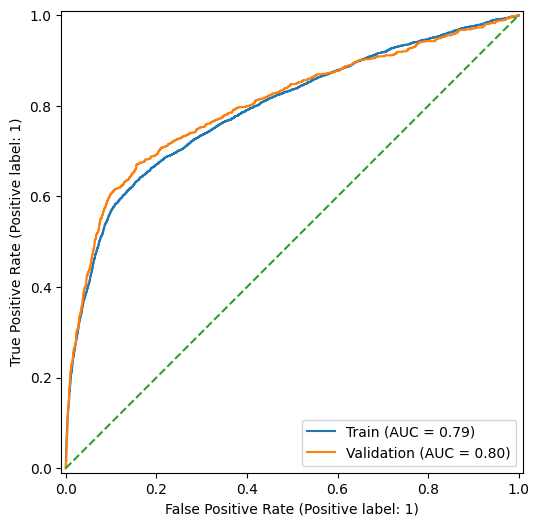

In [45]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(model, X_train, train_targets, name="Train", ax=ax)
RocCurveDisplay.from_estimator(model, X_val, val_targets, name="Validation", ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--")
plt.show()

З графіку видно, що обидві криві значно вищі діагоналі, особливо на початку - тому модель працює краще за випадкове вгадування

**kNN-модель**

In [46]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
train_with_target = X_train.copy()
train_with_target['y'] = train_targets
train_with_target.corr()['y'].to_frame().style.background_gradient()

,y
age,0.028673
campaign,-0.065462
pdays,-0.325539
previous,0.229759
emp.var.rate,-0.293690
cons.price.idx,-0.132520
cons.conf.idx,0.055327
euribor3m,-0.303174
nr.employed,-0.349729
job_admin.,0.029864


<Axes: xlabel='age', ylabel='euribor3m'>

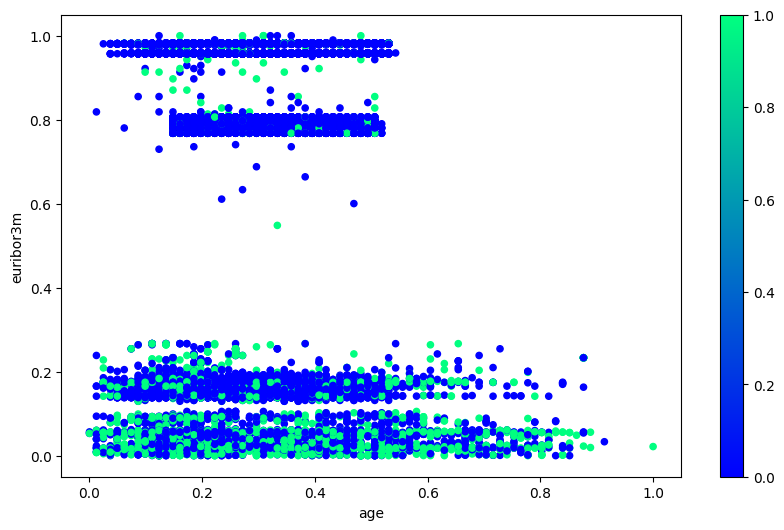

In [48]:
X_train.plot.scatter(
    x='age',
    y='euribor3m',
    c=train_targets,
    cmap='winter',
    figsize=(10, 6)
)

In [49]:
from sklearn.neighbors import KNeighborsClassifier

In [50]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [51]:
# Розраховуємо значення для train i val набрів за допомогою моделі Knn
train_preds_knn = knn.predict_proba(X_train)[:, 1]
val_preds_knn = knn.predict_proba(X_val)[:, 1]

In [52]:
# Оцінюємо результат в порівнянні з реальними даними
train_auc_knn = roc_auc_score(train_targets, train_preds_knn)
val_auc_knn = roc_auc_score(val_targets, val_preds_knn)

print("Train AUROC:", train_auc_knn)
print("Validation AUROC:", val_auc_knn)
print("Gap:", train_auc_knn - val_auc_knn)

Train AUROC: 0.9246071065332432
Validation AUROC: 0.7240867788574933
Gap: 0.2005203276757499


Train ROC-AUC - дуже високий, а Validation ROC-AUC помітно менший, - це говорить про перенавченість моделі на даних train.

Використовуючи GridSearchCV знайдемо оптимальне значення параметра n_neighbors для класифікатора kNN

In [53]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': list(range(1, 25))}

In [54]:
knn_gs = GridSearchCV(knn,param_grid, cv=5, scoring='roc_auc', n_jobs=-1)


In [55]:
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24]},
             scoring='roc_auc')

In [56]:
knn_best = knn_gs.best_estimator_
print("Найкраще значення гіперпараметра:", knn_gs.best_params_)
print("Кількість найкращих фолдів:", knn_gs.best_score_)

Найкраще значення гіперпараметра: {'n_neighbors': 24}
Кількість найкращих фолдів: 0.7542708438752314


In [57]:
knn_gs.best_estimator_

KNeighborsClassifier(n_neighbors=24)

In [58]:
train_preds_knn_best = knn_best.predict_proba(X_train)[:, 1]
val_preds_knn_best = knn_best.predict_proba(X_val)[:, 1]

train_auc_knn_best = roc_auc_score(train_targets, train_preds_knn_best)
val_auc_knn_best = roc_auc_score(val_targets, val_preds_knn_best)

print("Train AUROC:", train_auc_knn_best)
print("Validation AUROC:", val_auc_knn_best)
print("Gap:", train_auc_knn_best - val_auc_knn_best)

Train AUROC: 0.8473525316015295
Validation AUROC: 0.7662069112929855
Gap: 0.081145620308544


Після підбору оптимального значення `n_neighbors` якість kNN-моделі покращилась.

Різниця між Train ROC-AUC та Validation ROC-AUC суттєво зменшилась, що свідчить про зниження overfitting та кращу здатність моделі узагальнювати нові дані.

Оптимальним значенням параметра виявилось `n_neighbors = 24`.

**Decision Tree**

In [59]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [60]:
model = DecisionTreeClassifier(random_state=42)

In [61]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [62]:
# Get predictions (probabilities for the positive class)
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# Calculate ROC AUC scores
train_auc_dt = roc_auc_score(train_targets, train_probs)
val_auc_dt = roc_auc_score(val_targets, val_probs)

print(f"Train ROC AUC: {train_auc_dt:.4f}")
print(f"Validation ROC AUC: {val_auc_dt:.4f}")

Train ROC AUC: 0.9999
Validation ROC AUC: 0.6261


Так як train_auc близький до 1.0, а val_auc значно нижчий (наприклад, 0.7), то модель перенавчена (overfitting).

In [63]:
print(f"Tree Depth: {model.get_depth()}")

Tree Depth: 35


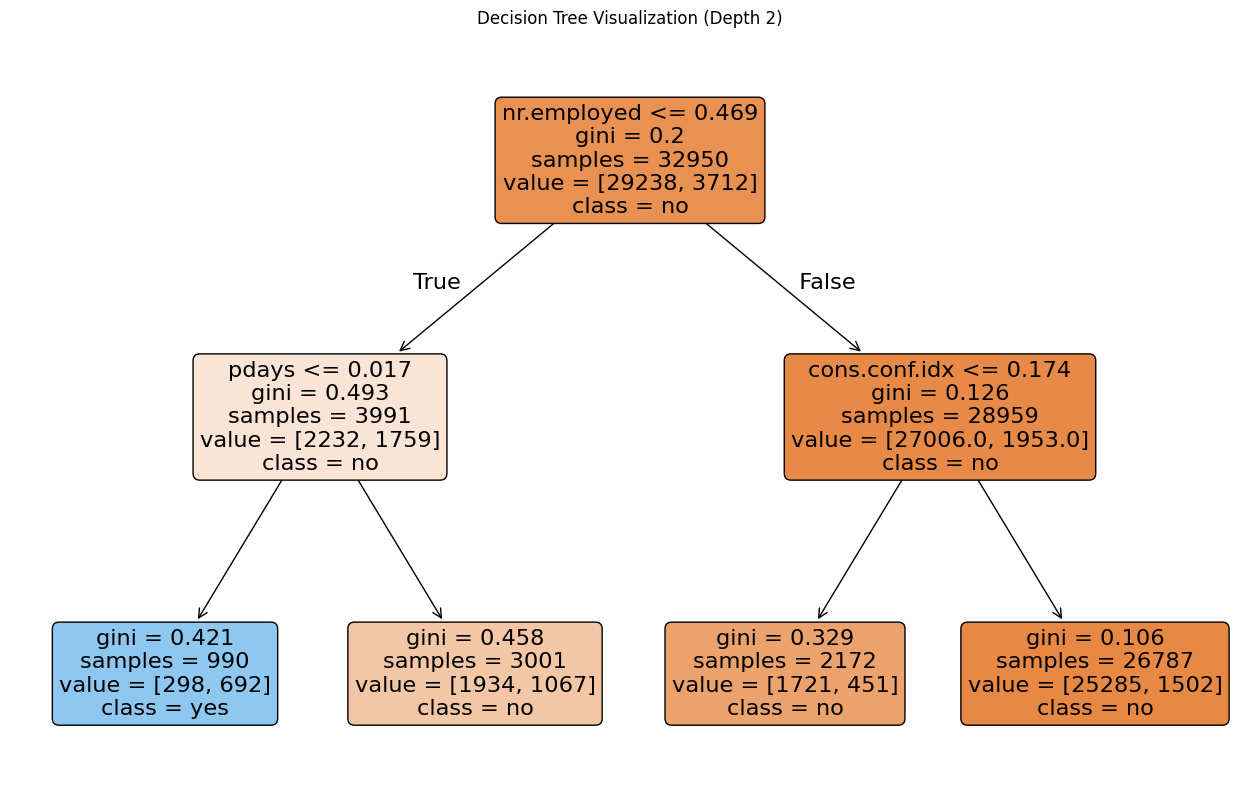

In [64]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train a simplified model for visualization
model_small = DecisionTreeClassifier(max_depth=2, random_state=42)
model_small.fit(X_train, train_targets)

# Visualize the tree structure
plt.figure(figsize=(16, 10))
plot_tree(
    model_small,
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    class_names=['no', 'yes']
)
plt.title("Decision Tree Visualization (Depth 2)")
plt.show()

Top 10 Most Influential Features:
          feature  importance
0             age    0.170590
8     nr.employed    0.155832
7       euribor3m    0.090647
1        campaign    0.082798
2           pdays    0.038512
33     housing_no    0.023431
34    housing_yes    0.022088
6   cons.conf.idx    0.021227
9      job_admin.    0.019008
35        loan_no    0.017777


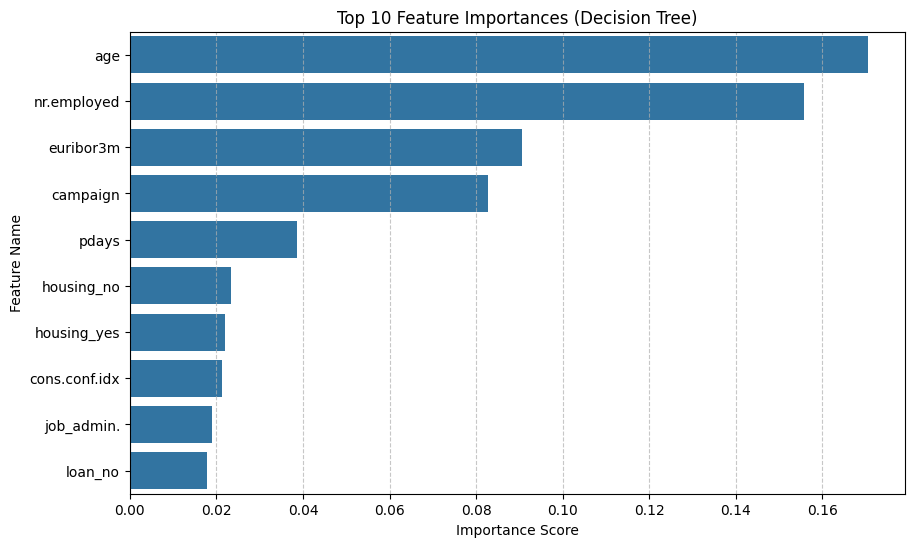

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a DataFrame with feature names and their importance scores
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Display the Top 10 most influential features
print("Top 10 Most Influential Features:")
print(importance_df.head(10))

# 3. Visualize the Top 10 features using a barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x='importance',
    y='feature'
)
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

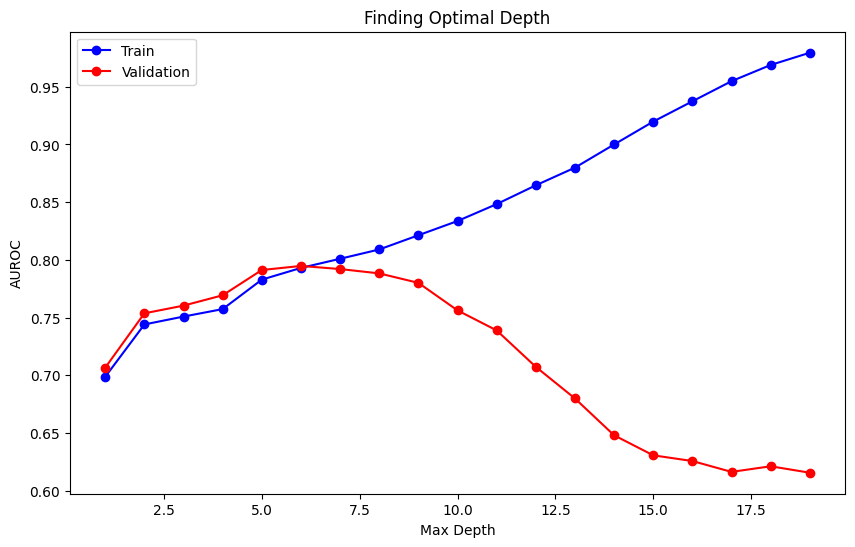

In [66]:
depths = range(1, 20)
train_aucs, val_aucs = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, train_targets)
    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_aucs, 'b-o', label='Train')
plt.plot(depths, val_aucs, 'r-o', label='Validation')
plt.title('Finding Optimal Depth')
plt.xlabel('Max Depth')
plt.ylabel('AUROC')
plt.legend()
plt.show()

Треба дивитися для більшого інтервалу по MaxDepth

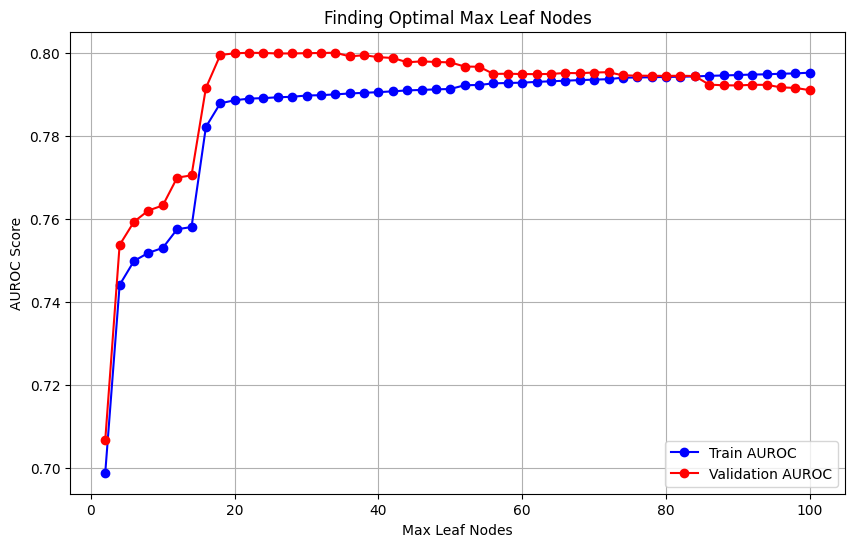

In [67]:
leaf_nodes = range(2, 101, 2) # Testing from 2 to 100 nodes
train_aucs, val_aucs = [], []

for n in leaf_nodes:
    model = DecisionTreeClassifier(max_leaf_nodes=n, random_state=42)
    model.fit(X_train, train_targets)

    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(leaf_nodes, train_aucs, 'b-o', label='Train AUROC')
plt.plot(leaf_nodes, val_aucs, 'r-o', label='Validation AUROC')
plt.title('Finding Optimal Max Leaf Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('AUROC Score')
plt.legend()
plt.grid(True)
plt.show()

In [68]:
def evaluate_model(max_depth: int = None, max_leaf_nodes: int = None):
    """
    Helper function to train and evaluate DecisionTreeClassifier
    """
    # 1. Initialize and train the model
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    )
    model.fit(X_train, train_targets)

    # 2. Get AUROC scores
    train_auc_dt = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auc_dt = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])

    print(f"Parameters: max_depth={max_depth}, max_leaf_nodes={max_leaf_nodes}")
    print(f"Train AUROC: {train_auc_dt:.4f} | Validation AUROC: {val_auc_dt:.4f}")
    print(f"Difference (Gap): {abs(train_auc_dt - val_auc_dt):.4f}")
    print("-" * 60)

    return val_auc_dt

    # --- experiments! ---

# 1. Start with a deep tree (Overfitting example)
evaluate_model(max_depth=20, max_leaf_nodes=None)

# 2. Try limiting depth
evaluate_model(max_depth=5, max_leaf_nodes=None)
evaluate_model(max_depth=7, max_leaf_nodes=None)

# 3. Try limiting leaf nodes
evaluate_model(max_depth=None, max_leaf_nodes=20)

# 4. Try a combination (The "Sweet Spot")
evaluate_model(max_depth=5, max_leaf_nodes=20)

# 5. Try a combination
evaluate_model(max_depth=5, max_leaf_nodes=50)

# 6. Try a combination
evaluate_model(max_depth=5, max_leaf_nodes=43)


Parameters: max_depth=20, max_leaf_nodes=None
Train AUROC: 0.9874 | Validation AUROC: 0.6187
Difference (Gap): 0.3687
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=None
Train AUROC: 0.7829 | Validation AUROC: 0.7912
Difference (Gap): 0.0083
------------------------------------------------------------
Parameters: max_depth=7, max_leaf_nodes=None
Train AUROC: 0.8010 | Validation AUROC: 0.7921
Difference (Gap): 0.0089
------------------------------------------------------------
Parameters: max_depth=None, max_leaf_nodes=20
Train AUROC: 0.7886 | Validation AUROC: 0.8000
Difference (Gap): 0.0113
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=20
Train AUROC: 0.7824 | Validation AUROC: 0.7913
Difference (Gap): 0.0089
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=50
Train AUROC: 0.7829 | Validation AUROC: 0.7912
Difference (Gap): 0.

np.float64(0.7912482605311572)

Оптимальний max_leaf_nodes=20, адже саме для нього Validation AUROC: 0.8000 - найкращий результат

**XGBoost**

In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

In [70]:
xgb_model.fit(X_train, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [71]:
train_preds_xgb = xgb_model.predict_proba(X_train)[:, 1]
val_preds_xgb = xgb_model.predict_proba(X_val)[:, 1]

train_auc_xgb = roc_auc_score(train_targets, train_preds_xgb)
val_auc_xgb = roc_auc_score(val_targets, val_preds_xgb)

print("Train AUROC:", train_auc_xgb)
print("Validation AUROC:", val_auc_xgb)
print("Gap:", train_auc_xgb - val_auc_xgb)

Train AUROC: 0.8443472554168996
Validation AUROC: 0.8150273155573375
Gap: 0.02931993985956205


XGBoost показав найркщі результати

# 5. Створити таблицю з порівнянням якості моделей

## Results of Models Comparison

| Model | Hyperparameters | Train ROC-AUC | Validation ROC-AUC | Comment |
|---|---|---:|---:|---|
| Logistic Regression | solver='liblinear' | 0.7933 | 0.8017 | Стабільна baseline-модель, без ознак overfitting. |
| kNN | n_neighbors=24 | 0.8474 | 0.7662 | Після tuning overfitting зменшився, але результат гірший за Logistic Regression. |
| Decision Tree | max_leaf_nodes=20 | 0.7886 | 0.8000 | Після обмеження дерева якість стала стабільною. |
| XGBoost | n_estimators=200, max_depth=4, learning_rate=0.1 | 0.8443 | 0.8150 | Найкраща модель за Validation ROC-AUC. |

### Висновки

У ході виконання задачі було протестовано кілька моделей машинного навчання для задачі бінарної класифікації.

Найкращий результат на validation-вибірці показала модель XGBoost. Вона продемонструвала найвище значення ROC-AUC та хороший баланс між train і validation метриками, що свідчить про хорошу здатність моделі узагальнювати нові дані.

Logistic Regression показала себе як найбільш стабільна модель — розрив між train та validation метриками був мінімальним.

Для kNN стало помітно, що модель схильна до overfitting при малих значеннях `n_neighbors`. Після підбору гіперпараметра результати стали кращими, а розрив між train і validation зменшився.

Decision Tree без обмежень дуже сильно переобучався, проте tuning параметрів `max_depth` та `max_leaf_nodes` дозволив суттєво покращити результати моделі.

Для оцінки моделей основною метрикою було обрано ROC-AUC, оскільки датасет є незбалансованим, а ця метрика краще відображає якість класифікації в таких задачах.

# 6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
- Sklearn: Randomized Search
- Hyperopt: Bayesian Optimization.
Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

In [75]:
from sklearn.model_selection import RandomizedSearchCV

In [76]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [77]:
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='auc'
    ),

    param_distributions=param_dist,

    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

НАвчання моделі:

In [78]:
xgb_random.fit(X_train, train_targets)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrai...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

Результати і оцінка моделі

In [81]:
xgb_best_random = xgb_random.best_estimator_

train_preds_xgb_random = xgb_best_random.predict_proba(X_train)[:, 1]
val_preds_xgb_random = xgb_best_random.predict_proba(X_val)[:, 1]

train_auc_xgb_random = roc_auc_score(
    train_targets,
    train_preds_xgb_random
)

val_auc_xgb_random = roc_auc_score(
    val_targets,
    val_preds_xgb_random
)

print("Train ROC-AUC:", train_auc_xgb_random)
print("Validation ROC-AUC:", val_auc_xgb_random)
print("Gap:", train_auc_xgb_random - val_auc_xgb_random)
print(xgb_random.best_params_)

Train ROC-AUC: 0.8245330736187673
Validation ROC-AUC: 0.811823670927874
Gap: 0.012709402690893268
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


Після застосування RandomizedSearchCV модель XGBoost стала більш стабільною — розрив між train та validation ROC-AUC суттєво зменшився.

Хоча validation ROC-AUC незначно знизився порівняно з базовою моделлю, tuning дозволив покращити здатність моделі до узагальнення та зменшити overfitting.

In [86]:
import optuna

In [87]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),

        'max_depth': trial.suggest_int('max_depth', 3, 6),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.2
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            1.0
        ),

        'random_state': 42,
        'eval_metric': 'auc'
    }

    xgb_optuna = XGBClassifier(**params)

    xgb_optuna.fit(X_train, train_targets)

    val_preds = xgb_optuna.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(val_targets, val_preds)

    return auc

In [88]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=20)

[I 2026-05-22 21:05:46,941] A new study created in memory with name: no-name-fbce9097-0f7c-4fa2-9f01-efc654615c87
[I 2026-05-22 21:05:48,128] Trial 0 finished with value: 0.8138292932449643 and parameters: {'n_estimators': 290, 'max_depth': 6, 'learning_rate': 0.0343969882221459, 'subsample': 0.7232153797116742, 'colsample_bytree': 0.9050895241439002}. Best is trial 0 with value: 0.8138292932449643.
[I 2026-05-22 21:05:48,724] Trial 1 finished with value: 0.8088001645124769 and parameters: {'n_estimators': 141, 'max_depth': 6, 'learning_rate': 0.12926119616872084, 'subsample': 0.7728117262209208, 'colsample_bytree': 0.948359944681635}. Best is trial 0 with value: 0.8138292932449643.
[I 2026-05-22 21:05:49,346] Trial 2 finished with value: 0.8123467645879522 and parameters: {'n_estimators': 218, 'max_depth': 3, 'learning_rate': 0.16464904164677824, 'subsample': 0.861726528351242, 'colsample_bytree': 0.7004481965527105}. Best is trial 0 with value: 0.8138292932449643.
[I 2026-05-22 21:05

In [89]:
print("Best params:")
print(study.best_params)

print("\nBest ROC-AUC:")
print(study.best_value)

Best params:
{'n_estimators': 298, 'max_depth': 5, 'learning_rate': 0.017805068561786097, 'subsample': 0.818232230294728, 'colsample_bytree': 0.8031968678498941}

Best ROC-AUC:
0.8162113336713996


Навчання best model

In [90]:
xgb_best_optuna = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='auc'
)

xgb_best_optuna.fit(X_train, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8031968678498941, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.017805068561786097,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=298, n_jobs=None,
              num_parallel_tree=None, ...)

Оцінка моделі

In [91]:
train_preds_xgb_optuna = xgb_best_optuna.predict_proba(X_train)[:, 1]

val_preds_xgb_optuna = xgb_best_optuna.predict_proba(X_val)[:, 1]

train_auc_xgb_optuna = roc_auc_score(
    train_targets,
    train_preds_xgb_optuna
)

val_auc_xgb_optuna = roc_auc_score(
    val_targets,
    val_preds_xgb_optuna
)

print("Train ROC-AUC:", train_auc_xgb_optuna)

print("Validation ROC-AUC:", val_auc_xgb_optuna)

print(
    "Gap:",
    train_auc_xgb_optuna - val_auc_xgb_optuna
)

Train ROC-AUC: 0.8294321832372726
Validation ROC-AUC: 0.8162113336713996
Gap: 0.013220849565872994


Висновок щодо Bayesian Optimization

Bayesian Optimization дозволила знайти найбільш ефективну конфігурацію гіперпараметрів для XGBoost.

Після tuning модель показала найкращий результат на validation-вибірці серед усіх протестованих моделей та зберегла хороший баланс між train і validation ROC-AUC, що свідчить про хорошу здатність моделі до узагальнення.

Ще раз порівняємо результати всіх моделей:

## Results of Models Comparison

| Model | Hyperparameters | Train ROC-AUC | Validation ROC-AUC | Gap | Comment |
|---|---|---:|---:|---:|---|
| Logistic Regression | solver='liblinear' | 0.7933 | 0.8017 | 0.0084 | Стабільна baseline-модель без ознак overfitting. |
| kNN (tuned) | n_neighbors=24 | 0.8474 | 0.7662 | 0.0811 | Після tuning overfitting зменшився, але результат залишився нижчим за інші моделі. |
| Decision Tree (tuned) | max_leaf_nodes=20 | 0.7886 | 0.8000 | 0.0113 | Після обмеження глибини та кількості leaf nodes модель стала більш стабільною. |
| XGBoost baseline | n_estimators=200, max_depth=4 | 0.8443 | 0.8152 | 0.0291 | Найкращий результат серед baseline-моделей. |
| XGBoost + RandomizedSearchCV | optimized hyperparameters | 0.8245 | 0.8118 | 0.0127 | Tuning зменшив overfitting та покращив здатність моделі до узагальнення. |
| XGBoost + Bayesian Optimization | optimized hyperparameters | 0.8294 | 0.8162 | 0.0132 | Найкращий результат серед усіх протестованих моделей. |

# 7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

In [92]:
importance_df_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_best_optuna.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

importance_df_xgb.head(10)

,feature,importance
8,nr.employed,0.403848
56,poutcome_success,0.057535
4,emp.var.rate,0.056818
47,month_oct,0.035589
6,cons.conf.idx,0.035479
2,pdays,0.033955
7,euribor3m,0.024043
44,month_mar,0.021476
45,month_may,0.020701
54,poutcome_failure,0.018292


З отриманої таблиці видно, що найбільший вплив на прогноз моделі має ознака `nr.employed`, що виглядає логічно, оскільки вона відображає загальний стан економіки та рівень зайнятості населення.

Також суттєвий вплив має `poutcome_success` — успішний результат попередньої маркетингової кампанії. Це теж виглядає цілком очікувано: якщо клієнт вже позитивно реагував раніше, ймовірність повторної позитивної відповіді зростає.

Модель також показує важливість показників (`emp.var.rate`, `euribor3m`, `cons.conf.idx`), що свідчить про залежність рішень клієнтів від економічної ситуації.

Деякі ознаки, пов’язані з місяцем контакту (`month_oct`, `month_mar`, `month_may`), також мають помітний вплив, що може вказувати на сезонність маркетингових кампаній.

# 9. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

In [94]:
import shap

In [95]:
explainer = shap.TreeExplainer(xgb_best_optuna)

In [96]:
X_sample = X_val.sample(1000, random_state=42)

In [97]:
shap_values = explainer.shap_values(X_sample)

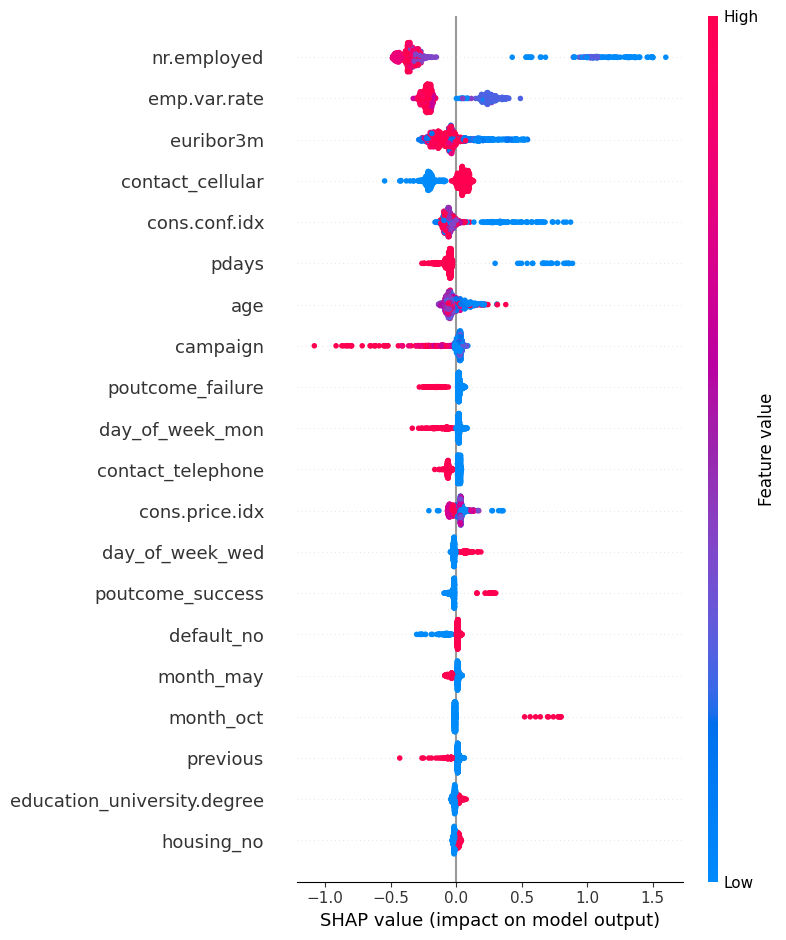

In [100]:
shap.summary_plot(
    shap_values,
    X_sample
)

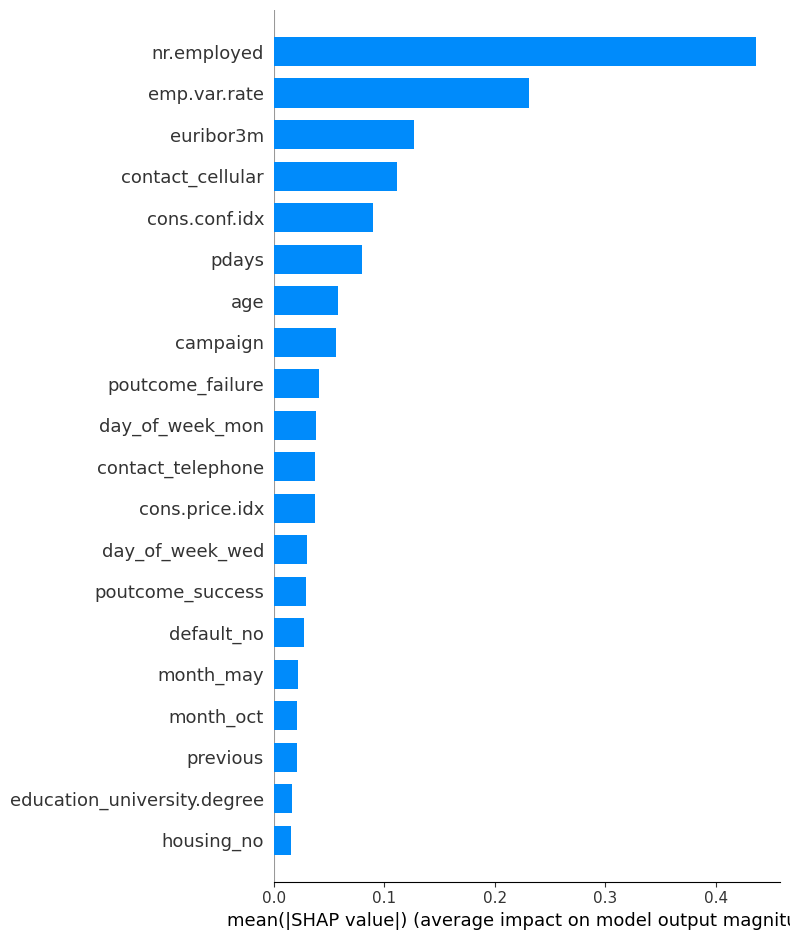

In [101]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar'
)

### SHAP Analysis

SHAP analysis підтвердив результати попереднього feature importance analysis.

Найбільший вплив на прогноз моделі мають макроекономічні показники:
- nr.employed
- emp.var.rate
- euribor3m
- cons.conf.idx

Це виглядає логічно, оскільки рішення клієнтів щодо відкриття депозиту суттєво залежать від економічної ситуації.

Також важливими виявилися ознаки, пов’язані з попередньою взаємодією з клієнтом:
- campaign
- pdays
- poutcome_success
- poutcome_failure

SHAP analysis також показує, що тип контакту (contact_cellular) має помітний вплив на прогноз моделі, що може свідчити про різну ефективність каналів комунікації, хоча я спочатку скептично сприйняла поділ на ці різні типи контакту


9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?

In [105]:
val_preds_xgb_optuna_binary = (
    val_preds_xgb_optuna >= 0.5
).astype(int)

In [106]:
errors_df = X_val.copy()

errors_df['actual'] = val_targets.values

errors_df['predicted'] = val_preds_xgb_optuna_binary

errors_df['probability'] = val_preds_xgb_optuna

In [107]:
mistakes_df = errors_df[
    errors_df['actual'] != errors_df['predicted']
]

In [108]:
mistakes_df[['actual', 'predicted']].value_counts()

,,count
actual,predicted,
1,0,695
0,1,111


тобто:
False Negative (actual=1, predicted=0)	- 695

False Positive (actual=0, predicted=1)	- 111

Це значить, що модель набагато частіше пропускає потенційних клієнтів, які могли б погодитися на депозит, ніж помилково прогнозує позитивну відповідь для клієнтів, які фактично відмовляться. Це частково пояснюється незбалансованістю даних, але банку варто звернути увагу на цей перекіс, щоб не втрачати вкладників депозитів.